# 📈 StockMindX — Exploratory Data Analysis
### AI-Powered Multi-Horizon Stock Price & Return Forecasting

This notebook explores the historical stock market dataset used to train the deep learning models in **StockMindX**.

### Objectives
- Explore historical OHLCV data
- Analyze price trends and return distributions
- Study volatility and cross-stock correlations
- Evaluate engineered technical indicators
- Validate feature quality before model training

**Before running:** generate the training data and features from the
project root:
```bash
python src/fetch_data.py
python src/features.py
```

> **Note:** This notebook is intended for exploratory analysis only. The Streamlit application uses trained TensorFlow/Keras models together with live Yahoo Finance data for inference.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

raw = pd.read_csv("../data/raw/stocks.csv", parse_dates=["Date"])
raw = raw.sort_values(["Ticker","Date"])

print("Rows:", len(raw))
print("Tickers:", sorted(raw["Ticker"].unique()))
print("Date range:", raw["Date"].min().date(), "to", raw["Date"].max().date())
raw.head()


Rows: 61005
Tickers: ['AAPL', 'AMD', 'AMZN', 'BAC', 'COST', 'CRM', 'CVX', 'DIS', 'GOOGL', 'GS', 'JNJ', 'JPM', 'META', 'MSFT', 'NFLX', 'NVDA', 'PFE', 'TGT', 'TSLA', 'WMT', 'XOM']
Date range: 2015-01-02 to 2026-07-23


,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,24.648441,24.659506,23.754468,24.192604,212818400,AAPL
1,2015-01-05,23.962471,24.042132,23.325184,23.511059,257142000,AAPL
2,2015-01-06,23.575233,23.772173,23.152587,23.513275,263188400,AAPL
3,2015-01-07,23.721278,23.942559,23.610638,23.842983,160423600,AAPL
4,2015-01-08,24.170481,24.816620,24.053201,24.759087,237458000,AAPL


## 1. Raw data overview

In [2]:
ticker_summary = raw.groupby("Ticker")["Close"].agg(["count","min","max","mean"]).round(2)
ticker_summary.columns=["Trading Days","Min Close","Max Close","Mean Close"]
display(ticker_summary)


,Trading Days,Min Close,Max Close,Mean Close
Ticker,,,,
AAPL,2905,20.57,333.74,114.37
AMD,2905,1.62,580.91,79.98
AMZN,2905,14.35,274.99,117.74
BAC,2905,8.87,61.62,28.36
COST,2905,111.07,1094.32,418.38
CRM,2905,53.13,363.22,171.17
CVX,2905,41.19,209.23,102.99
DIS,2905,76.91,195.76,110.19
GOOGL,2905,24.63,402.38,105.34


## 2. Price trends

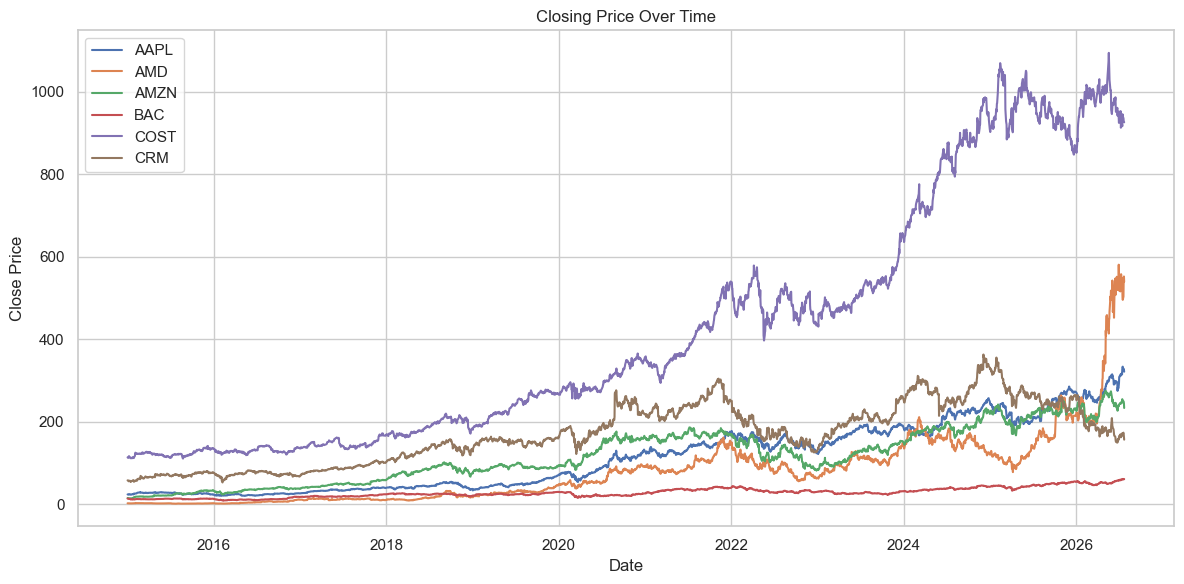

In [3]:
sample_tickers = sorted(raw["Ticker"].unique())[:6]

plt.figure(figsize=(12,6))
for t in sample_tickers:
    d = raw[raw["Ticker"]==t]
    plt.plot(d["Date"], d["Close"], label=t)

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Return distribution

Log returns should look roughly bell-shaped but with fatter tails than a
true normal distribution (the well-known "fat tails" property of financial
returns) -- worth checking skew/kurtosis directly rather than assuming
normality, since that assumption underlies the simple confidence intervals
used later in the app.


Mean: 0.00072
Std: 0.02166
Skew: -0.133
Kurtosis: 17.498


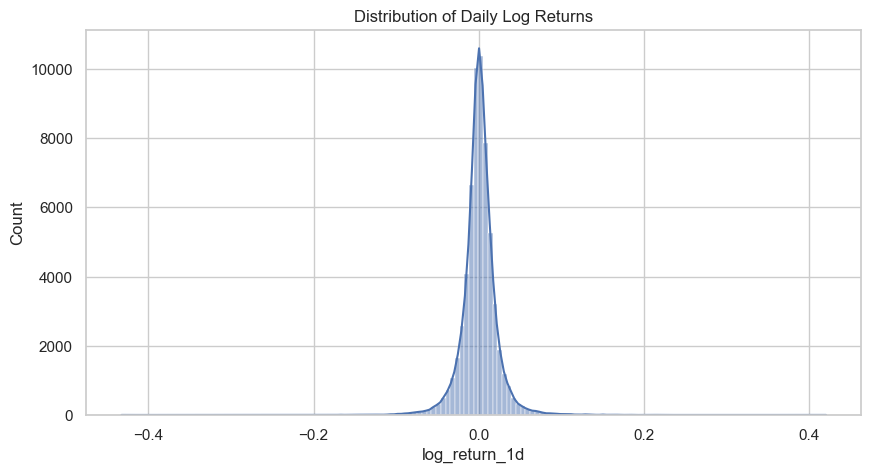

In [4]:
raw["log_return_1d"] = raw.groupby("Ticker")["Close"].transform(
    lambda s: np.log(s/s.shift(1))
)

returns = raw["log_return_1d"].dropna()

print("Mean:", round(returns.mean(),5))
print("Std:", round(returns.std(),5))
print("Skew:", round(returns.skew(),3))
print("Kurtosis:", round(returns.kurtosis(),3))

plt.figure(figsize=(10,5))
sns.histplot(returns,bins=150,kde=True)
plt.title("Distribution of Daily Log Returns")
plt.show()


## 4. Volatility clustering

A well-known stylized fact: large moves tend to cluster in time (calm
periods followed by calm periods, volatile periods followed by volatile
periods) rather than volatility being i.i.d. day to day. This is part of
the motivation for including rolling volatility as a model feature.


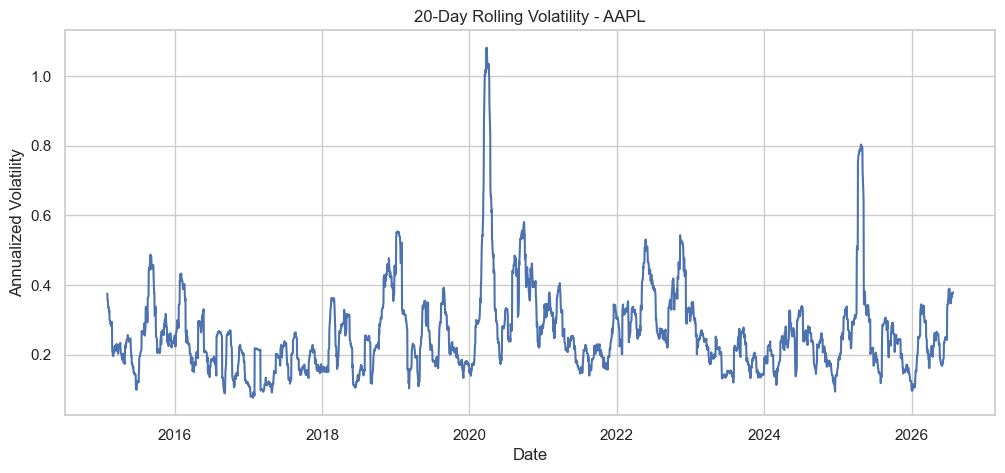

In [5]:
example_ticker = sample_tickers[0]
g = raw[raw["Ticker"]==example_ticker].copy()
g["rolling_vol_20d"] = g["log_return_1d"].rolling(20).std()*np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(g["Date"],g["rolling_vol_20d"])
plt.title(f"20-Day Rolling Volatility - {example_ticker}")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()


## 5. Cross-ticker return correlation

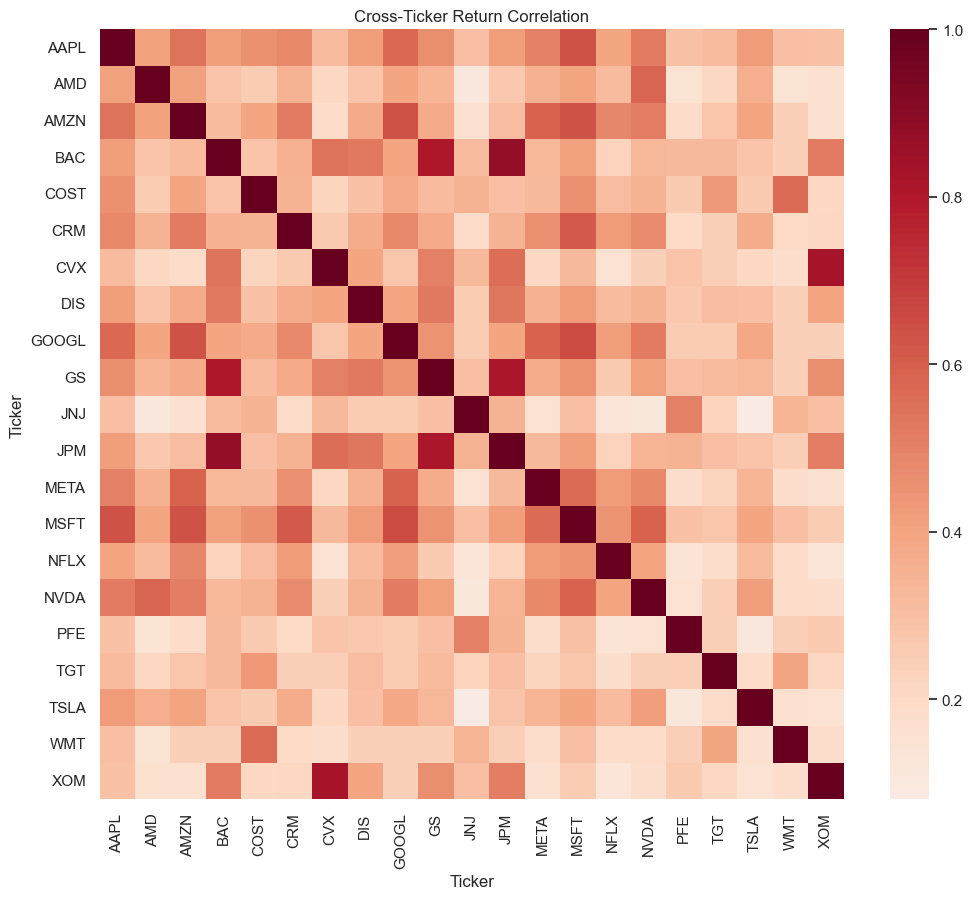

In [6]:
pivot_returns = raw.pivot(index="Date",columns="Ticker",values="log_return_1d")
corr = pivot_returns.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,cmap="RdBu_r",center=0)
plt.title("Cross-Ticker Return Correlation")
plt.show()


## 6. Engineered features

Load the processed feature table (output of `src/features.py`) and check
for the two things that matter most before trusting any of these features
in a model: (a) they don't leak the target, and (b) they actually
correlate with it at least weakly.


In [7]:
from features import FEATURE_COLUMNS, HORIZONS

feat_df = pd.read_parquet("../data/processed/features.parquet")
display(feat_df[FEATURE_COLUMNS].describe().T)


,count,mean,std,min,25%,50%,75%,max
log_return_1d,59556.0,0.000724,0.021674,-0.432578,-0.008321,0.000743,0.010196,0.420617
volatility_20d,59556.0,0.294827,0.177479,0.043620,0.178225,0.246936,0.356040,1.747324
price_to_sma_20,59556.0,0.007537,0.052244,-0.463180,-0.018288,0.007785,0.033370,0.550250
price_to_sma_50,59556.0,0.019757,0.085144,-0.463648,-0.025999,0.019003,0.062238,0.952599
rsi_14,59556.0,53.666104,17.177774,0.000000,41.295901,53.820588,66.254710,100.000000
macd,59556.0,0.657676,4.238546,-35.583228,-0.475875,0.261868,1.455851,52.845967
macd_hist,59556.0,0.000918,1.270395,-19.137601,-0.257650,0.005030,0.277851,14.216833
momentum_10,59556.0,0.009483,0.066845,-0.518052,-0.024403,0.008109,0.041481,0.658833
bb_pct_b,59556.0,0.558144,0.324823,-0.486204,0.299478,0.596895,0.818841,1.524741
atr_14,59556.0,3.350894,4.074618,0.009467,0.846593,1.984142,4.163603,40.508182


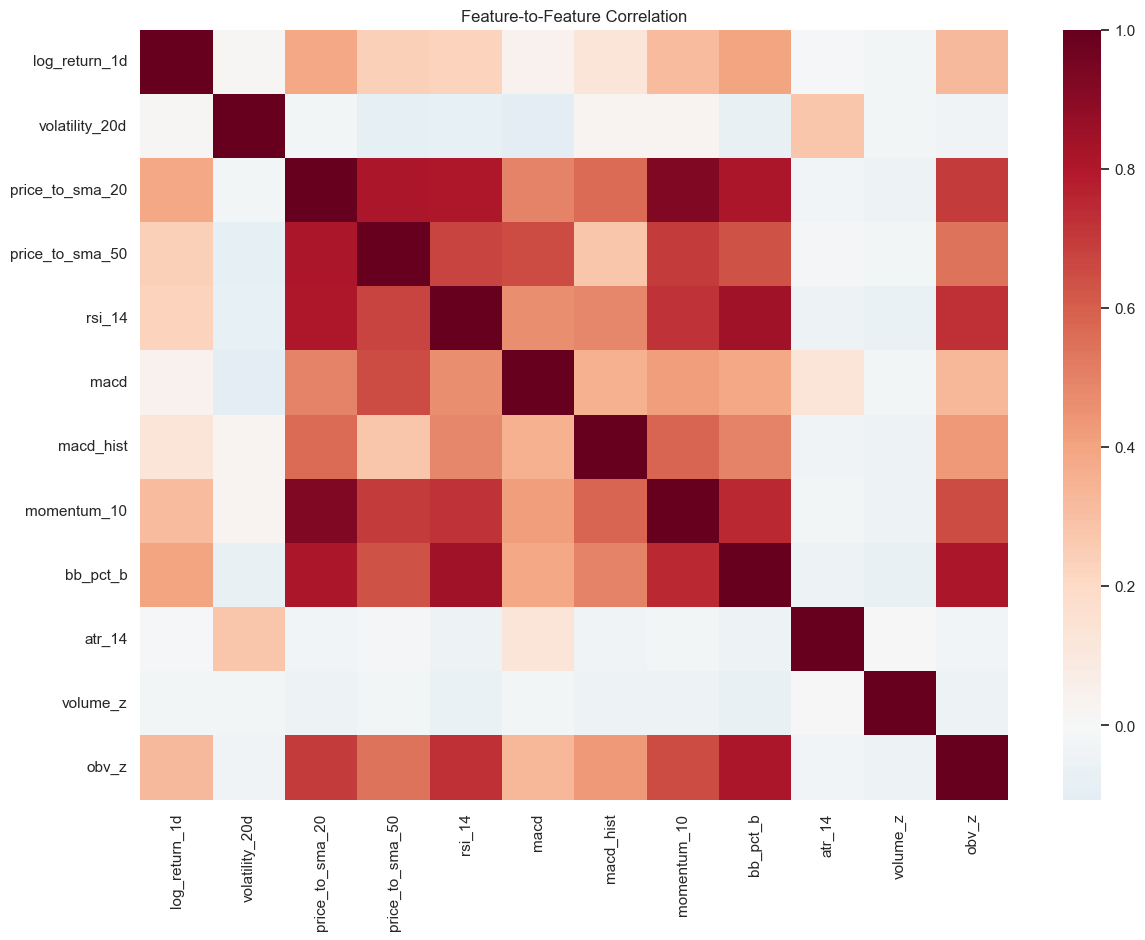

In [8]:
plt.figure(figsize=(14,10))
sns.heatmap(feat_df[FEATURE_COLUMNS].corr(), cmap="RdBu_r", center=0)
plt.title("Feature-to-Feature Correlation")
plt.show()

### Which features correlate with the forward-return targets?

This is a quick, honest sanity check -- if every correlation below is
close to zero, that's not a bug in the notebook, it's a real property of
short-horizon stock returns (see the "efficient market" disclosure in the
main README and the app's Model Comparison tab).


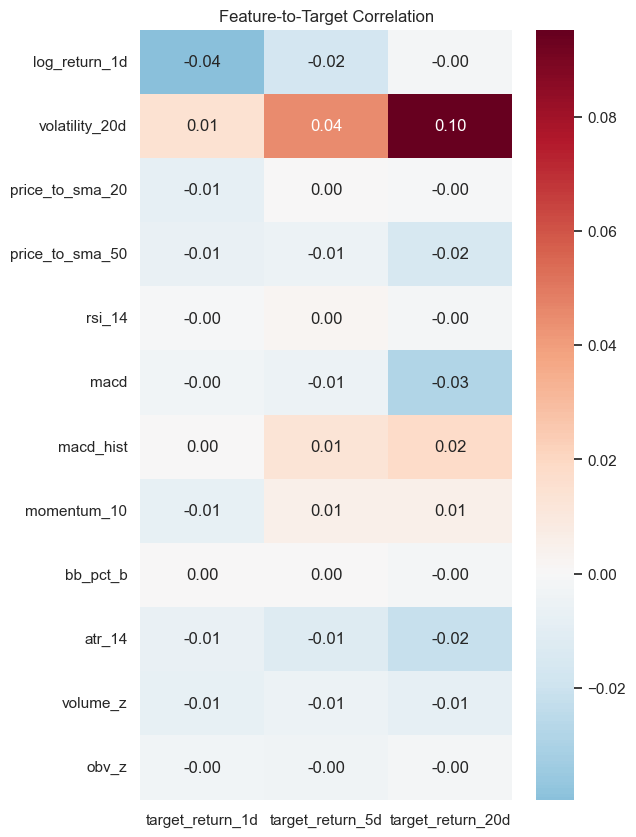

In [9]:
target_cols = [f"target_return_{h}d" for h in HORIZONS]
corr_target = feat_df[FEATURE_COLUMNS+target_cols].corr()[target_cols].drop(index=target_cols)

plt.figure(figsize=(6,10))
sns.heatmap(corr_target,annot=True,cmap="RdBu_r",center=0,fmt=".2f")
plt.title("Feature-to-Target Correlation")
plt.show()


## 7. Autocorrelation of returns

Checks whether past returns predict future returns at all (a weak-form
market efficiency check), using pandas' built-in lag autocorrelation
rather than pulling in a separate stats library for a single number.


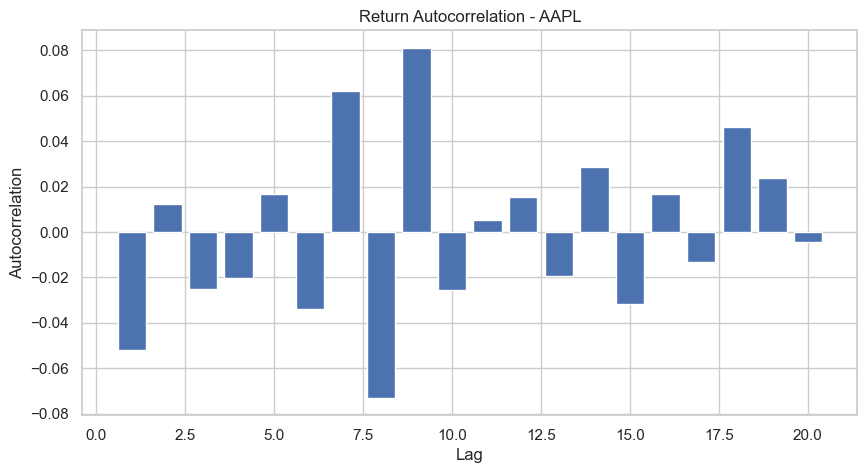

In [10]:
lags = range(1,21)
autocorrs = [g["log_return_1d"].autocorr(lag=i) for i in lags]

plt.figure(figsize=(10,5))
plt.bar(lags,autocorrs)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title(f"Return Autocorrelation - {example_ticker}")
plt.show()

## 8. Takeaways for modeling

- Returns are approximately mean-zero with fat tails -- consistent with
  using a robust loss (Huber) rather than plain MSE during training.
- Volatility clusters over time -- supports including rolling volatility
  (`volatility_20d`, `atr_14`) as model inputs.
- Feature-to-feature correlation shows which indicators are near-duplicates
  (e.g. closely related moving-average ratios) -- informs which indicators
  are safe to prune without losing information.
- Feature-to-target correlations are small in magnitude for most
  indicators at short horizons, which is the expected, honest result for
  liquid large-cap stocks -- not a data or pipeline bug.
- Return autocorrelation near zero at most lags is consistent with weak-
  form market efficiency, matching the "models barely beat the naive
  baseline at 1 day" finding reported in the app.

---

### Where to go next
- **Train the models** on this data: `python src/train.py --epochs 15`
- **See live forecasts**: `streamlit run app/app.py`
